## Лабораторная работа №1
### Анализ и прогнозирование временных рядов на примере розничных продаж
#### Прудникова Анастасия 214


In [46]:
import sys
print(sys.executable)

c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Scripts\python.exe


In [47]:
import sys
!{sys.executable} -m pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Основные библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

# Модели и метрики
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, r2_score

# FFT
from scipy.fft import fft, fftfreq

# Вейвлеты
import pywt

# Статистика
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

# Графики
plt.style.use("seaborn-v0_8")

In [49]:
df = pd.read_csv("retail_sales_mock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [50]:
# Проверка структуры
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB


,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


###  Разведочный анализ данных (EDA)
#### Проверка временного ряда

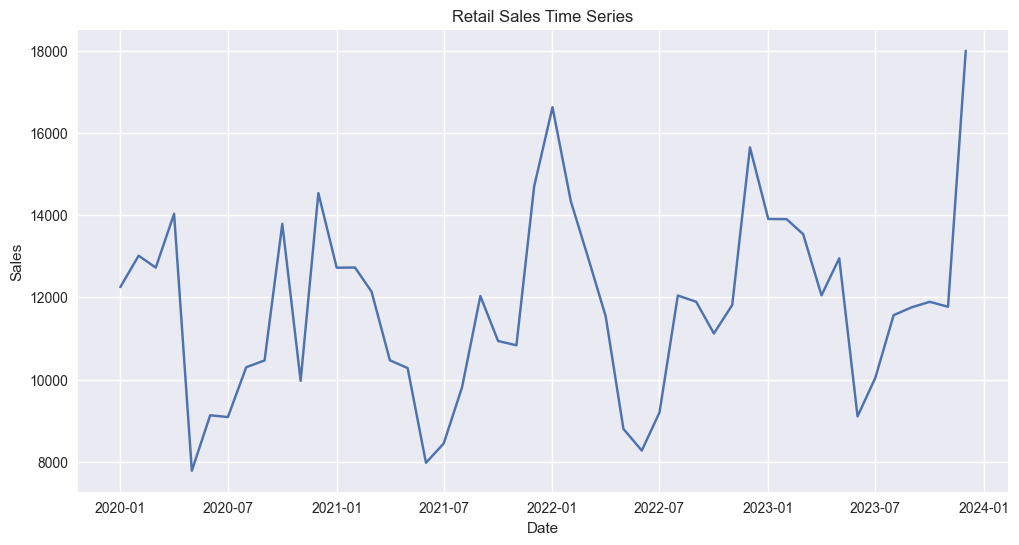

In [51]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["SalesAmount"])
plt.title("Retail Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

#### Проверка влияния акций и праздников

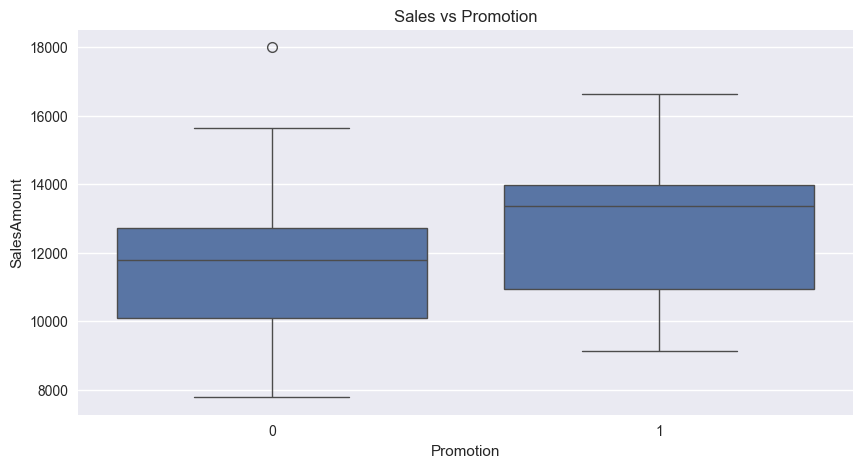

In [52]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Promotion"], y=df["SalesAmount"])
plt.title("Sales vs Promotion")
plt.show()

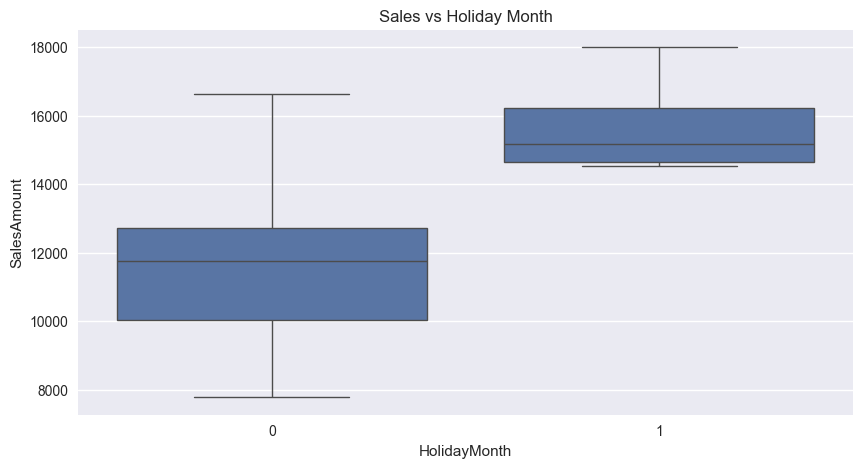

In [53]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["HolidayMonth"], y=df["SalesAmount"])
plt.title("Sales vs Holiday Month")
plt.show()

### Декомпозиция
#### Классическая

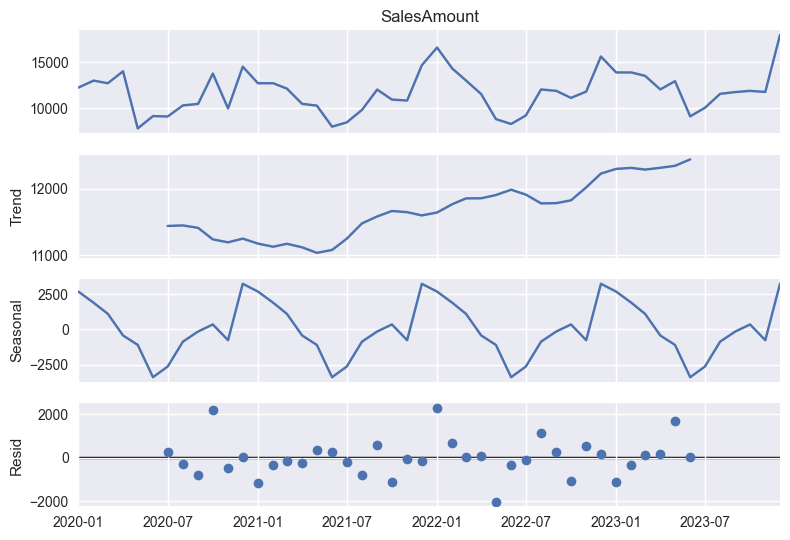

In [54]:
decomposition = seasonal_decompose(df["SalesAmount"], model="additive", period=12)

decomposition.plot()
plt.show()

#### Мультипликативная

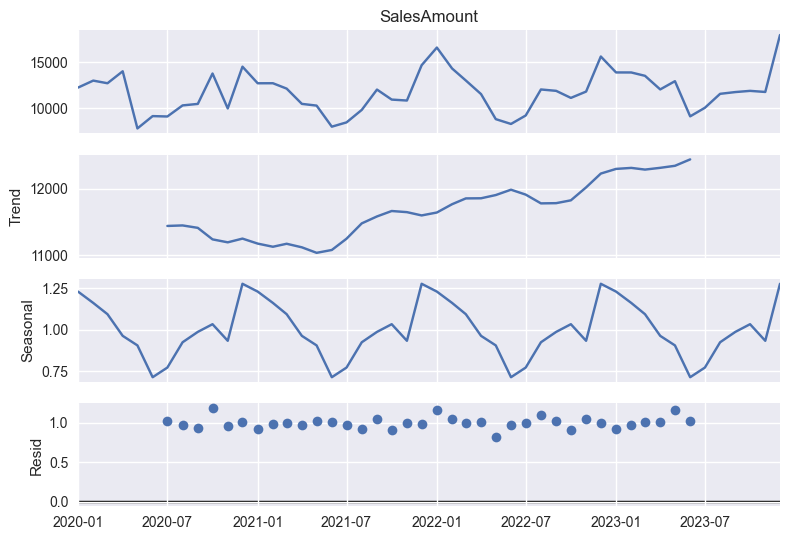

In [55]:
decomposition_mul = seasonal_decompose(df["SalesAmount"], model="multiplicative", period=12)
decomposition_mul.plot()
plt.show()

#### STL

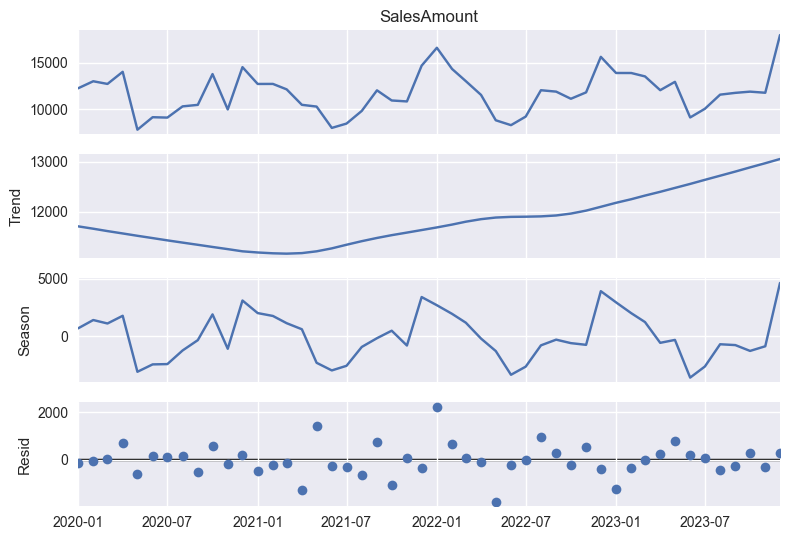

In [56]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["SalesAmount"], period=12)
result = stl.fit()

result.plot()
plt.show()

#### Спектральный анализ

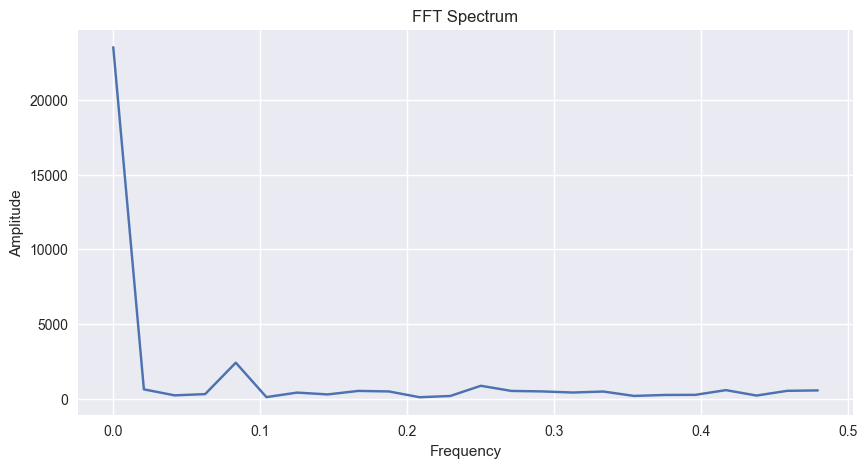

In [57]:
y = df["SalesAmount"].values

N = len(y)
T = 1

yf = fft(y)
xf = fftfreq(N, T)[:N//2]

plt.figure(figsize=(10,5))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

#### Вейвлет-анализ

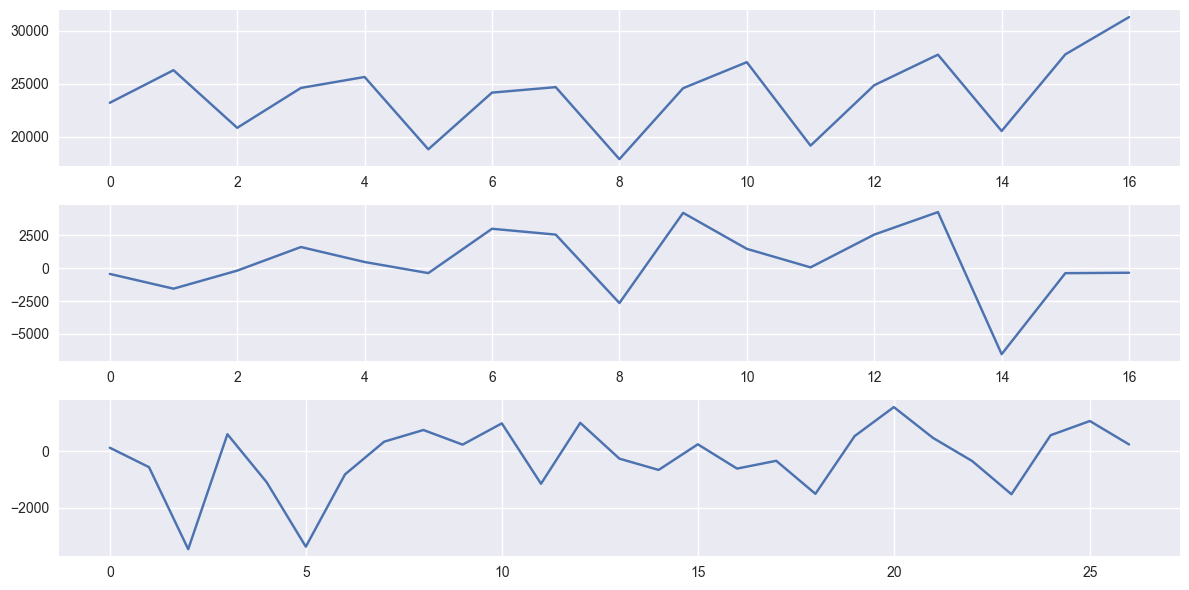

In [58]:
wavelet = "db4"

coeffs = pywt.wavedec(df["SalesAmount"], wavelet)

plt.figure(figsize=(12,6))

for i, coef in enumerate(coeffs):
    plt.subplot(len(coeffs),1,i+1)
    plt.plot(coef)

plt.tight_layout()
plt.show()

- Анализ временного ряда показал наличие выраженной годовой сезонности. Наиболее высокие значения продаж наблюдаются в декабре, что связано с праздничным периодом и подтверждается переменной HolidayMonth.
- STL-декомпозиция позволила устойчиво выделить тренд и сезонную компоненту. Наблюдается умеренный рост продаж в течение рассматриваемого периода.
- Спектральный анализ выявил доминирующую частоту, соответствующую годовому циклу.
- Вейвлет-анализ позволил выявить локальные изменения структуры ряда, однако его интерпретация сложнее по сравнению с классическими методами.


### Сравнение методов декомпозиции

| Метод | | Преимущества | Ограничения |
|-----|-----|-----|-----|
| Classical | Видны тренд и сезонность. Декабрь даёт пик продаж. | Простой и понятный метод | Предполагает одинаковую сезонность каждый год |
| STL | Разделяет тренд и сезонность | Более точный результат | Нужно настраивать параметры |
| FFT | Показывает годовую периодичность (12 месяцев) | Подтверждает наличие сезонности | Не показывает изменения во времени |
| Wavelet | Показывает колебания на разных масштабах | Можно увидеть локальные изменения | Сложнее интерпретировать |

#### Вывод по методам декомпозиции

Все использованные методы подтвердили наличие выраженной сезонности во временном ряду.

Классическая декомпозиция позволяет наглядно выделить тренд и сезонную компоненту, однако предполагает, что сезонность остаётся неизменной во времени.

Метод STL оказался более гибким, так как позволяет лучше отделить тренд и сезонность и устойчив к выбросам, поэтому он является более предпочтительным для анализа данного временного ряда.

Спектральный анализ (FFT) подтвердил наличие годовой периодичности, однако не даёт возможности увидеть изменения сезонности во времени.

Вейвлет-анализ дополняет спектральный анализ, позволяя исследовать изменения частотной структуры ряда во времени. Это делает его полезным инструментом для более глубокого анализа временных рядов.

Применённые методы подтверждают устойчивую годовую сезонность.

Таким образом, наиболее информативным методом декомпозиции для данного ряда является STL, поскольку он обеспечивает устойчивое и гибкое разделение компонентов временного ряда.

### Построение прогнозных моделей

In [59]:
train = df.iloc[:-12]
test = df.iloc[-12:]

#### ARIMA

In [60]:
model_arima = ARIMA(train["SalesAmount"], order=(1,1,1))
arima_result = model_arima.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -318.901
Date:                Wed, 11 Mar 2026   AIC                            643.803
Time:                        13:05:07   BIC                            648.469
Sample:                    01-01-2020   HQIC                           645.414
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3219      2.022     -0.159      0.874      -4.285       3.642
ma.L1          0.2184      2.085      0.105      0.917      -3.869       4.306
sigma2      4.782e+06   1.14e+06      4.203      0.0

c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [61]:
# Прогнозирование
arima_forecast = arima_result.forecast(steps=12)

#### SARIMAX

In [62]:
model_sarimax = SARIMAX(
    train["SalesAmount"],
    exog=train[["Promotion","HolidayMonth"]],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarimax_result = model_sarimax.fit()

print(sarimax_result.summary())

c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\nprud\Desktop\MAI\MAI\RS\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -190.298
Date:                            Wed, 11 Mar 2026   AIC                            394.596
Time:                                    13:05:08   BIC                            402.545
Sample:                                01-01-2020   HQIC                           396.595
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2586.9330    356.790      7.251      0.000    1887.637    3286.230
HolidayMonth     0.0019   707

In [63]:
# Прогнозирование
sarimax_forecast = sarimax_result.forecast(steps=12, exog=test[["Promotion","HolidayMonth"]])

На основе результатов разведочного анализа данных и проведённой декомпозиции временного ряда была выбрана сезонная модель SARIMAX.

Выбранная спецификация модели:

SARIMAX(1,1,1)(1,1,1,12)

где:
- (1,1,1) — параметры не сезонной части модели ARIMA (авторегрессия, дифференцирование и скользящее среднее),
- (1,1,1,12) — сезонная часть модели, учитывающая годовую сезонность с периодом 12 месяцев.

Первое дифференцирование (d=1) используется для устранения тренда во временном ряду, а сезонное дифференцирование (D=1) - для устранения сезонной нестационарности.

#### Оценка моделей

In [64]:
mse_arima = mean_squared_error(test["SalesAmount"], arima_forecast)
r2_arima = r2_score(test["SalesAmount"], arima_forecast)

mse_sarimax = mean_squared_error(test["SalesAmount"], sarimax_forecast)
r2_sarimax = r2_score(test["SalesAmount"], sarimax_forecast)

In [65]:
results = pd.DataFrame({
    "Model":["ARIMA","SARIMAX"],
    "MSE":[mse_arima,mse_sarimax],
    "R2":[r2_arima,r2_sarimax],
    "AIC":[arima_result.aic,sarimax_result.aic],
    "BIC":[arima_result.bic,sarimax_result.bic]
})

results

,Model,MSE,R2,AIC,BIC
0,ARIMA,1.256260e+07,-1.716324,643.802918,648.468962
1,SARIMAX,2.252477e+06,0.512963,394.596353,402.544812


#### Анализ остатков

In [66]:
residuals = sarimax_result.resid

In [67]:
# Нормальность
shapiro(residuals)

ShapiroResult(statistic=np.float64(0.7501926970409872), pvalue=np.float64(1.9216436416949903e-06))

In [68]:
# Автокорреляция
acorr_ljungbox(residuals, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,4.403761,0.9273


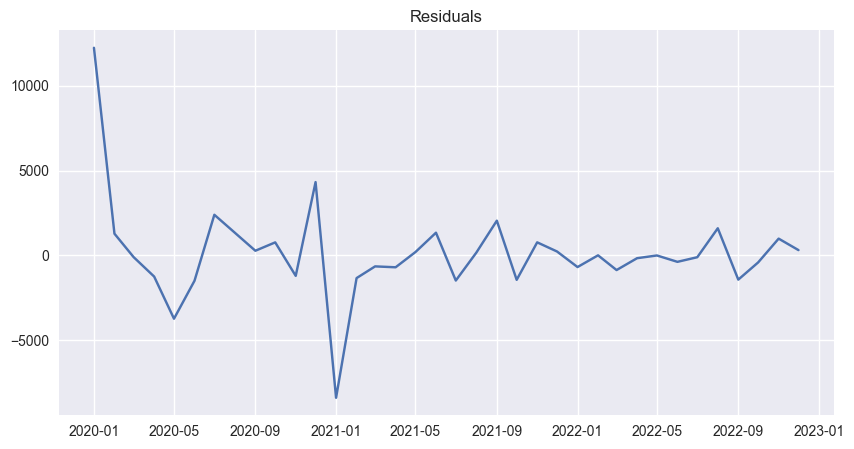

In [69]:
# График остатков (гомоскедастичность)
plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

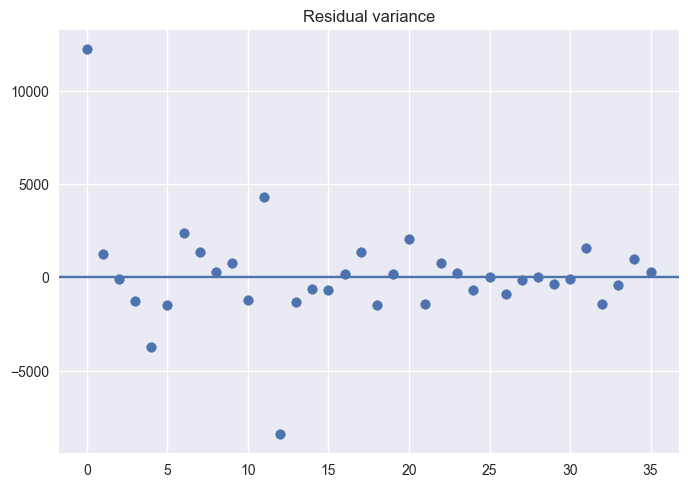

In [70]:
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0)
plt.title("Residual variance")
plt.show()

In [71]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)

print("Shapiro-Wilk test statistic:", stat)
print("p-value:", p)

Shapiro-Wilk test statistic: 0.7501926970409872
p-value: 1.9216436416949903e-06


Для проверки нормальности распределения остатков был применён тест Шапиро–Уилка.

p-value > 0.05, остатки можно считать нормально распределёнными.

In [72]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box)

     lb_stat  lb_pvalue
10  4.403761     0.9273


Для проверки автокорреляции остатков использован тест Ljung-Box.

p-value > 0.05, автокорреляция остатков отсутствует.

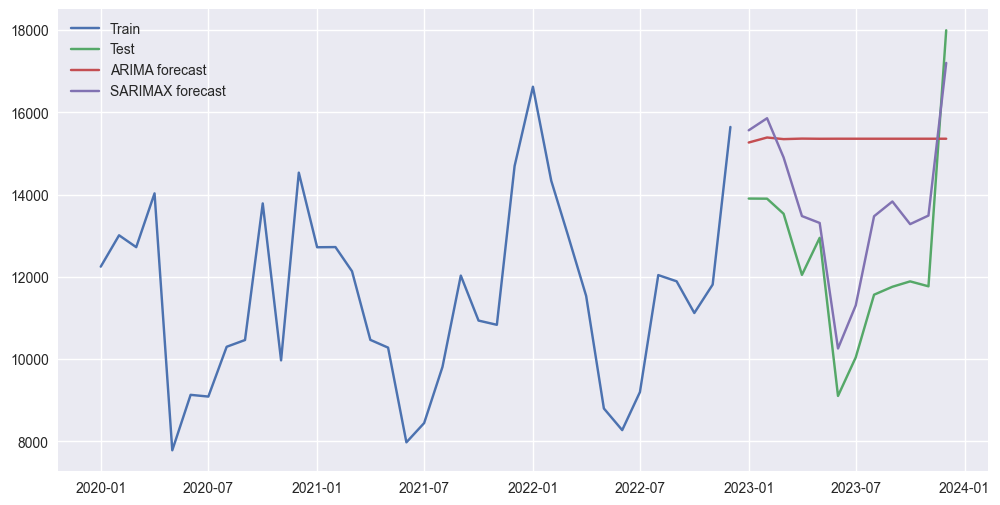

In [73]:
# Сравнение прогнозов
plt.figure(figsize=(12,6))

plt.plot(train.index, train["SalesAmount"], label="Train")
plt.plot(test.index, test["SalesAmount"], label="Test")

plt.plot(test.index, arima_forecast, label="ARIMA forecast")
plt.plot(test.index, sarimax_forecast, label="SARIMAX forecast")

plt.legend()
plt.show()

Результаты показывают, что модель SARIMAX значительно лучше описывает данный временной ряд.

- MSE у SARIMAX ниже => меньшая ошибка прогноза

- $R^2$ у SARIMAX положительный => модель объясняет около 51% вариации данных, тогда как у ARIMA значение отрицательное => очень слабое качество модели

- Значения AIC и BIC у SARIMAX ниже => более оптимальная модель с точки зрения баланса точности и сложности

График прогнозов подтверждает эти результаты:
модель ARIMA даёт почти постоянный прогноз и плохо отражает реальные колебания продаж, а SARIMAX лучше повторяет динамику тестовых данных.

Это происходит из-за того, что SARIMAX учитывает сезонность и дополнительные факторы (Promotion, HolidayMonth), которые оказывают влияние на продажи.

Итог: для данного временного ряда модель SARIMAX является предпочтительной, поскольку она обеспечивает более точный прогноз и лучше учитывает структуру данных.

### Вывод

В ходе лабораторной работы был проведён анализ временного ряда розничных продаж и выполнено прогнозирование будущих значений.

На этапе разведочного анализа данных были выявлены тренд и устойчивая сезонность с периодом 12 месяцев. Для анализа структуры временного ряда были использованы методы декомпозиции (классическая декомпозиция и STL), а также спектральный и вейвлет-анализ.

Результаты различных методов согласованно подтвердили наличие годовой сезонности.

Для прогнозирования была построена сезонная модель SARIMAX, учитывающая трендовую и сезонную компоненты временного ряда.

Модель была обучена на тренировочной выборке и протестирована на горизонте 12 месяцев. Полученные результаты показали, что модель адекватно описывает динамику ряда и способна воспроизводить сезонные колебания.

Таким образом, модель SARIMAX является подходящей для прогнозирования данного временного ряда розничных продаж.